### <center> Programming and Numerical Methods for Economics  
##### <center> Case Study: Uganda ISA-LSMS

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

## Change this path to the one where you save the functions.py file
os.chdir('C:/Users/jzurita/OneDrive - University of Edinburgh/Courses/Programming Numerical Methods/Week 3')
from functions import  gini

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
#display options
pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_columns', None)  # or 1000
pd.set_option('display.max_rows', None)  # or 1000
pd.set_option('display.max_colwidth', None)  # or 199
percentiles = [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]

#### Import Data

In [7]:
data = pd.read_csv("data13.csv")

In [9]:
# Check 1: 
count_months = data.groupby(by=['year','month']).count() ##Survey not uniformly implemented across months.

In [11]:
count_yearmonth = pd.value_counts(data['month'])
### pd.value_counts is a series method (doesnt work with dataframes) To apply it to a dataframe
### we need to use .apply() method.

####  SUMMARY STATS

In [13]:
# CONSUMPTION SUMMARY 
sum_c = data[["ctotal",'ctotal_cap',"ctotal_dur","ctotal_gift","cfood"]].describe()
print('=============================================')
print(sum_c)
# Poor country: average per capita cons at 408$. Most consumption is on food (above50%) and gifts are important

print(sum_c.to_latex())

        ctotal  ctotal_cap  ctotal_dur  ctotal_gift    cfood
count 2,951.00    2,950.00    2,951.00     2,951.00 2,951.00
mean  1,789.74      400.93    2,155.32       161.38 1,121.14
std   1,169.08      370.88    1,593.82       247.62   674.73
min     312.67       42.46      316.52         0.00   137.69
25%     986.20      197.66    1,104.61        27.83   652.04
50%   1,452.86      301.04    1,666.71        92.78   957.83
75%   2,238.02      454.49    2,700.27       201.79 1,427.20
max   8,039.11    5,410.05   14,881.73     4,884.63 5,064.54
\begin{tabular}{lrrrrr}
\toprule
 & ctotal & ctotal_cap & ctotal_dur & ctotal_gift & cfood \\
\midrule
count & 2951.000000 & 2950.000000 & 2951.000000 & 2951.000000 & 2951.000000 \\
mean & 1789.741802 & 400.931325 & 2155.317179 & 161.377943 & 1121.135422 \\
std & 1169.082415 & 370.876506 & 1593.822826 & 247.623715 & 674.727878 \\
min & 312.672746 & 42.461970 & 316.519063 & 0.000000 & 137.694297 \\
25% & 986.203511 & 197.655293 & 1104.608236 & 27.8

Food transfers in poor countries are large

In [15]:
data['share_gift'] = (data['ctotal_gift'])/data['ctotal']
print('=============================================')
print('Share of household consumption coming from gifts/transfers:', round(100*np.mean(data['share_gift']),2))


Share of household consumption coming from gifts/transfers: 10.87


In [17]:
# INCOME SUMMARY
sum_inc = data[["inctotal",'inctotal_cap',"wage_total","bs_profit","revenue_agr_p_c_district","profit_lvstk"]].describe(percentiles=percentiles)
print('=============================================')
print(sum_inc)
# Most households are (subsistence) farmers. Farming is the main source of income for households in Uganda.

# WEALTH SUMMARY
# Note: For land value, I had to estimate it using different datasets and matching on plot characteristics
sum_wealth = data[["asset_value", 'wealth_agrls', 'land_value_hat']].describe(percentiles=percentiles)
print('=============================================')
print(sum_wealth)

# SOCIODEM SUMMARY
sum_sociodem = data[["age", "illdays", "urban","female","familysize","bednet", "writeread"]].describe()
print('=============================================')
print(sum_sociodem)

       inctotal  inctotal_cap  wage_total  bs_profit  \
count  2,951.00      2,950.00    1,092.00   1,358.00   
mean   1,859.70        424.80    1,186.42   1,325.55   
std    2,443.31        677.04    1,370.22   2,159.16   
min       14.79          1.64        5.80    -231.94   
5%        94.20         20.53       44.67      36.33   
10%      172.02         36.03       75.92      69.00   
25%      379.15         78.23      228.46     185.55   
50%    1,001.12        204.33      742.20     556.65   
75%    2,319.39        492.80    1,623.57   1,516.01   
90%    4,454.66      1,028.49    2,783.26   3,247.14   
95%    6,757.92      1,580.95    4,098.36   5,479.78   
max   17,732.50      9,422.41    8,349.79  16,003.77   

       revenue_agr_p_c_district  profit_lvstk  
count                  2,387.00        665.00  
mean                     912.90        239.65  
std                    1,653.17        275.23  
min                        0.00        -28.61  
5%                        25.66

Most population live in rural areas. Average household size is 5-6 members. Many households have bednets. Few household heads know to read and write.

####  CIW urban vs rural inequality

In [19]:
# Using groupby
CIW_avg = data[['ctotal','inctotal','wtotal','urban']].groupby(by='urban').mean()

Let's create a better summary of urban vs rural including inequality measures:

In [21]:
CIW_UGA = []
var_list = ['ctotal','inctotal','wtotal']
for var in var_list:
    mean_var = [var,np.mean(data[var].dropna()), np.mean(data.loc[data['urban'] == 0][var].dropna()), np.mean(data.loc[data['urban'] == 1][var].dropna())]
    gini_var = [' ',gini(data[var].dropna()), gini(data.loc[data['urban'] == 0][var].dropna()), gini(data.loc[data['urban'] == 1][var].dropna())]
    CIW_UGA.append(mean_var)
    CIW_UGA.append(gini_var)

sum_ciw_uga = pd.DataFrame(data=CIW_UGA, columns=['', 'Nationwide', 'Rural', 'Urban'])
print('=============================================')
print(sum_ciw_uga)

             Nationwide    Rural    Urban
0    ctotal    1,789.74 1,573.02 2,502.58
1                  0.33     0.31     0.32
2  inctotal    1,859.70 1,584.34 2,765.43
3                  0.58     0.58     0.53
4    wtotal    5,240.28 4,474.93 7,757.69
5                  0.67     0.62     0.76


#### TAKEAWAYS
CIW INEQUALITY ORDER MAKE SENSE: Consumption inequality is lower than income inequality which is lower than wealth inequality. Make sense theoretically. Make sense also empirical. Same trends in other African countries, also in europe and US. HIGH INEQUALITY. Even for being a household survey that doesnt over-sample the rich (we miss the billonaires, the people working in the government,etc). also survey does not include luxury goods, people from government or big companies, money in banks, etc...! EVEN IN RURAL AREAS INEQUALITY IS HIGH: Not everyone is equally poor, even when we think of the context of very poor villages. WE OBSERVE A BIT THAT RURAL AREAS ARE POORER BUT MORE EQUAL (CW). Result in Magalhaes, Santaeulalia-Llopis.  MUCH LOWER TRANSMISSION OF INCOME INEQUALITY TO CONSUMPTION INEQUALITY. Redistribution? Insurance?.

#### Plot distributions

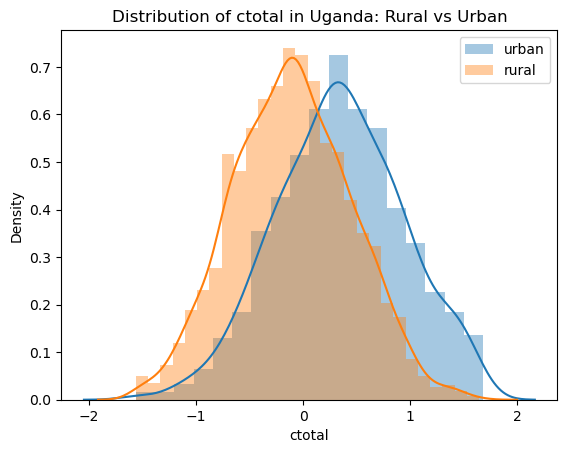

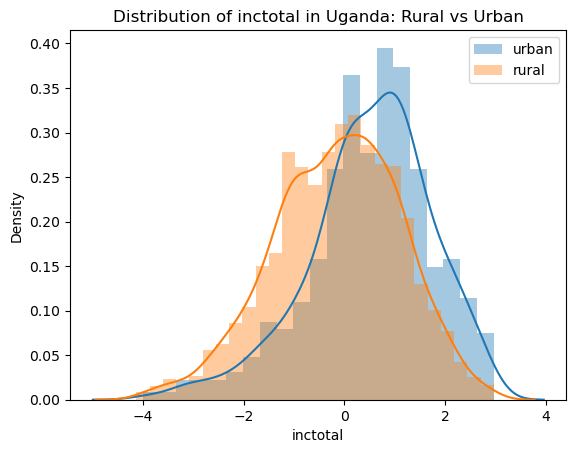

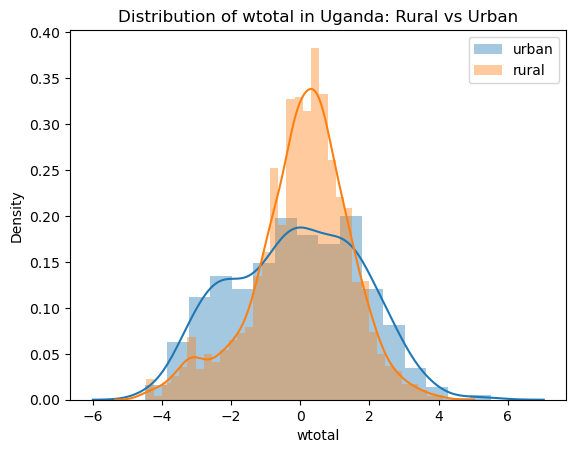

In [23]:
var_list = ['ctotal','inctotal','wtotal']
for var in var_list:
    fig, ax = plt.subplots()
    sns.distplot((np.log(data.loc[data['urban'] == 1][var]).replace([-np.inf, np.inf], np.nan)).dropna()-np.mean((np.log(data[var]).replace([-np.inf, np.inf], np.nan)).dropna()), label='urban')
    sns.distplot((np.log(data.loc[data['urban'] == 0][var]).replace([-np.inf, np.inf], np.nan)).dropna()-np.mean((np.log(data[var]).replace([-np.inf, np.inf], np.nan)).dropna()), label='rural')
    plt.title('Distribution of '+var+' in Uganda: Rural vs Urban')
    plt.xlabel(var)
    ax.legend()
    plt.show()

#### Answer: Plot cumulative distributions

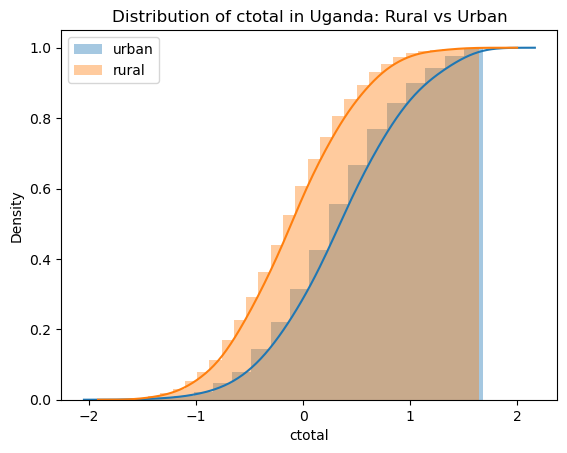

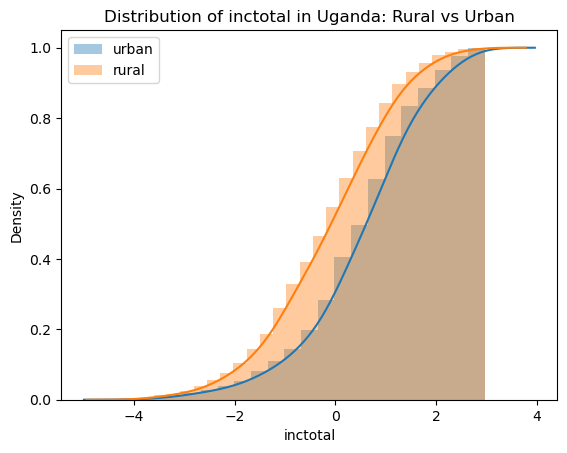

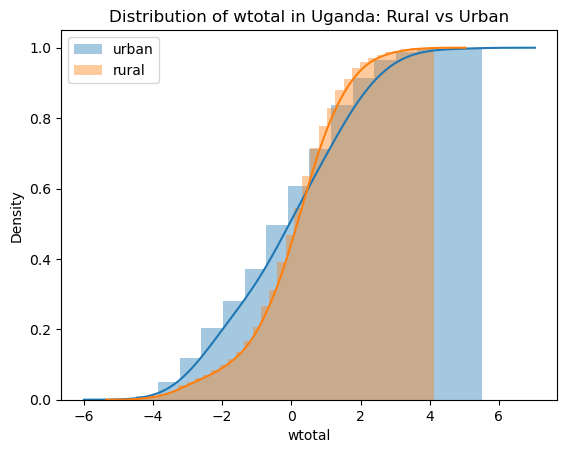

In [54]:
for var in var_list:
    fig, ax = plt.subplots()
    sns.distplot((np.log(data.loc[data['urban'] == 1][var]).replace([-np.inf, np.inf], np.nan)).dropna()-np.mean((np.log(data[var]).replace([-np.inf, np.inf], np.nan)).dropna()), label='urban', hist_kws=dict(cumulative=True),kde_kws=dict(cumulative=True))
    sns.distplot((np.log(data.loc[data['urban'] == 0][var]).replace([-np.inf, np.inf], np.nan)).dropna()-np.mean((np.log(data[var]).replace([-np.inf, np.inf], np.nan)).dropna()), label='rural', hist_kws=dict(cumulative=True),kde_kws=dict(cumulative=True))
    plt.title('Distribution of '+var+' in Uganda: Rural vs Urban')
    plt.xlabel(var)
    ax.legend()
    plt.show()

#### Lifecycle

In [37]:
# Drop extreme values (too few observations to get means and variance within age)
data = data[data['age'] < 80]
data = data[data['age'] >18]

#### Lifecycle  Urban vs rural

In [39]:
data["reside"] = np.where(data['urban']==1, 'Urban', 'Rural')

#### Consumption

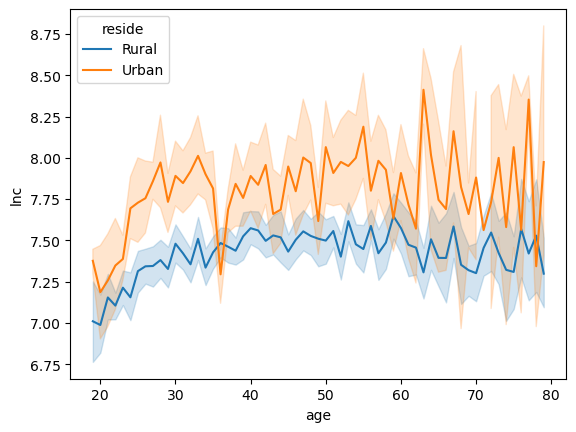

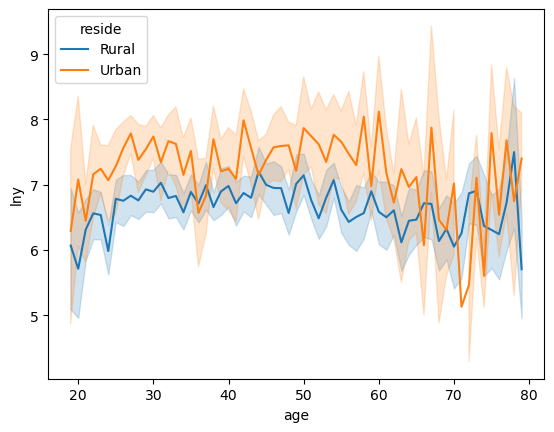

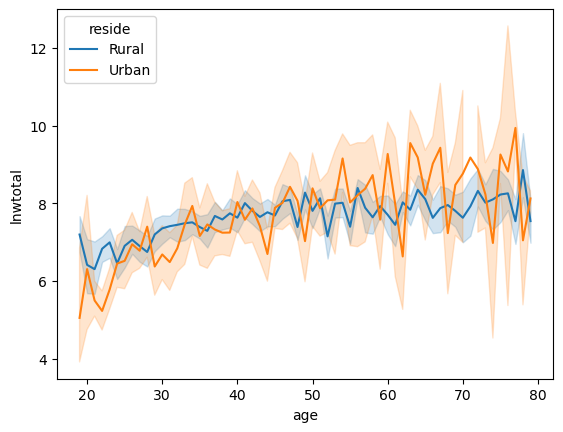

In [41]:
fig, ax = plt.subplots()
#sns.lineplot('age', 'lnc', hue='reside', data=data)
sns.lineplot(data=data,x='age', y='lnc', hue='reside')
plt.show()
# Income
fig, ax = plt.subplots()
#fig = sns.lineplot('age', 'lny', hue='reside', data=data)
fig = sns.lineplot(data=data,x='age', y='lny', hue='reside')
plt.show()
# Wealth 
fig, ax = plt.subplots()   
#fig = sns.lineplot('age', 'lnwtotal', hue='reside', data=data)
fig = sns.lineplot(data=data,x='age', y='lnwtotal', hue='reside')
plt.show()

#### Group the ages in bins

In [43]:
bins = [18, 30, 40, 50, 60, 80]
labels = [25, 35, 45, 55, 70]
data['age_bins'] = pd.cut(data['age'],bins=bins, labels=labels)

In [45]:
# If we want to save the plots: True/False
save_plot = True

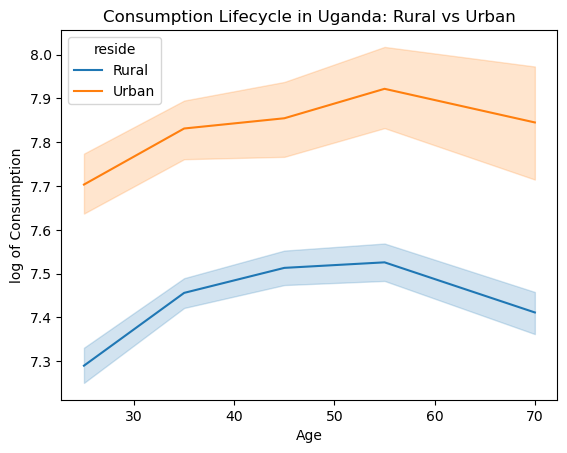

In [47]:
#Consumption Lifecycle  Urban vs rural
fig, ax = plt.subplots()
fig1 = sns.lineplot(x='age_bins', y='lnc', hue='reside', data=data)
plt.title('Consumption Lifecycle in Uganda: Rural vs Urban')
plt.ylabel('log of Consumption')
plt.xlabel('Age')
if save_plot == True:
    fig.savefig('lifecycle_C_urbrur')
plt.show()

#### Income Lifecycle  Urban vs rural

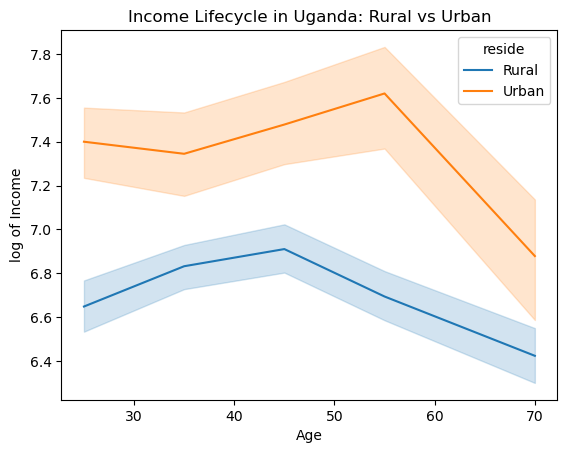

In [49]:
fig, ax = plt.subplots()
sns.lineplot(x='age_bins', y='lny', hue='reside', data=data)
plt.title('Income Lifecycle in Uganda: Rural vs Urban')
plt.ylabel('log of Income')
plt.xlabel('Age')
if save_plot == True:
    fig.savefig('lifecycle_I_urbrur')
plt.show()

In [ ]:
# Wealth Lifecycle  Urban vs rural

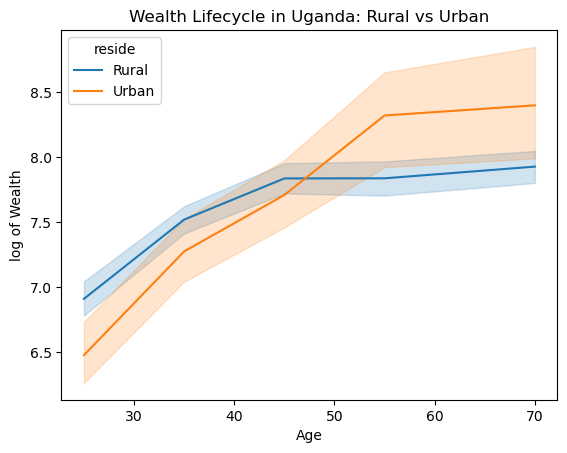

In [86]:
fig, ax = plt.subplots()   
sns.lineplot(x='age_bins', y='lnwtotal', hue='reside', data=data)
plt.title('Wealth Lifecycle in Uganda: Rural vs Urban')
plt.ylabel('log of Wealth')
plt.xlabel('Age')
if save_plot == True:
    fig.savefig('lifecycle_W_urbrur')
plt.show()

#### Male vs Female head of the household lifecycle:

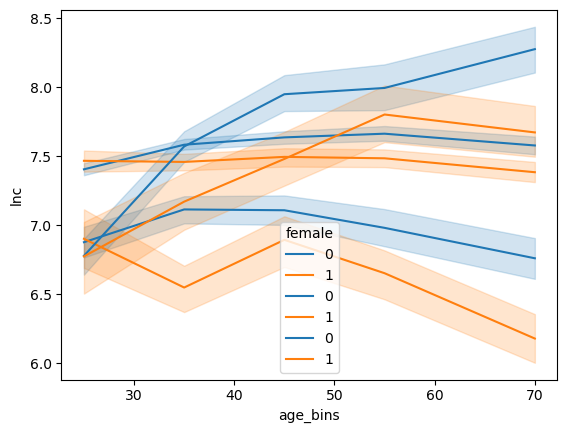

In [51]:
# #Consumption
# fig = sns.lineplot(x='age_bins', y='lnc', hue='female', data=data)

# #Income
# fig = sns.lineplot(x='age_bins', y='lny', hue='female', data=data)

# # Wealth    
# fig = sns.lineplot(x='age_bins', y='lnwtotal', hue='female', data=data)